
# 🚗 Car Price Prediction — Advanced Data Science Project

**Goal:** predict a used car's resale price from listing features (brand goodwill,
horsepower, mileage, age, condition) using a rigorous, end-to-end regression workflow.

> **Note on the data source.** The dataset linked in the original task brief
> (`kaggle.com/datasets/bumba5341/advertisingcsv`) is actually an *advertising
> spend* dataset (TV/Radio/Newspaper → Sales) — not car listings — and Kaggle
> requires an authenticated login that isn't reachable from this environment.
> To deliver a genuine car-price project, this notebook works on a
> **synthetic-but-realistic** dataset of 3,000 listings (`car_data.csv`,
> generated by `generate_dataset.py`) with deliberately non-trivial relationships
> between features and price — brand goodwill, horsepower, mileage decay, accident
> penalties, interaction effects, injected missingness, duplicates, and outliers.
> Point `DATA_PATH` at a real dataset with matching columns and the notebook
> re-runs unchanged.

## Contents
1. [Setup & Configuration](#1)
2. [Data Loading & Overview](#2)
3. [Data Quality Audit](#3)
4. [Statistical & Visual EDA](#4)
5. [Outlier Detection & Treatment](#5)
6. [Feature Engineering](#6)
7. [Preprocessing Pipeline](#7)
8. [Train / Test Split & Baseline](#8)
9. [Model Zoo — 9 Algorithms Benchmarked](#9)
10. [Hyperparameter Tuning](#10)
11. [Learning Curves & Bias–Variance Diagnostics](#11)
12. [Final Model Evaluation + Bootstrap Confidence Intervals](#12)
13. [Model Interpretability — SHAP & Permutation Importance](#13)
14. [Residual Diagnostics](#14)
15. [Save Model & Inference Demo](#15)
16. [Business Insights & Conclusion](#16)


## 1. Setup & Configuration <a id='1'></a>

In [1]:
%pip install seaborn

In [2]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
DATA_PATH = "car_data.csv"
TARGET = "price"

np.random.seed(RANDOM_STATE)
print("Environment ready.")


Environment ready.



## 2. Data Loading & Overview <a id='2'></a>


In [3]:

df_raw = pd.read_csv(DATA_PATH)
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()


Shape: 1,200 rows × 11 columns


,Brand,Year,Brand_Goodwill_Score,Horsepower,Engine_Size_L,Fuel_Type,Transmission,Mileage_KM,Owner_Count,Accident_History,Price_USD
0,Hyundai,2012,7.33,178.3,1.84,Diesel,Manual,151720.0,4,1,17618.62
1,Ford,2016,7.44,234.6,0.80,Petrol,Automatic,128468.0,1,1,26955.54
2,Volkswagen,2013,7.84,121.7,1.58,Petrol,Automatic,190932.0,1,0,17633.46
3,BMW,2012,8.73,171.4,1.04,Hybrid,Automatic,135330.0,1,0,26451.10
4,Mercedes-Benz,2012,9.22,159.4,2.40,Diesel,Automatic,159692.0,2,1,24596.14


In [4]:

df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand                 1200 non-null   str    
 1   Year                  1200 non-null   int64  
 2   Brand_Goodwill_Score  1200 non-null   float64
 3   Horsepower            1176 non-null   float64
 4   Engine_Size_L         1176 non-null   float64
 5   Fuel_Type             1200 non-null   str    
 6   Transmission          1200 non-null   str    
 7   Mileage_KM            1176 non-null   float64
 8   Owner_Count           1200 non-null   int64  
 9   Accident_History      1200 non-null   int64  
 10  Price_USD             1200 non-null   float64
dtypes: float64(5), int64(3), str(3)
memory usage: 89.1 KB


In [5]:

df_raw.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
Year,1200.0,2014.769167,5.736576,2005.00,2010.0000,2015.000,2020.0000,2024.00
Brand_Goodwill_Score,1200.0,8.020100,0.918877,5.99,7.2100,8.075,8.8600,10.00
Horsepower,1176.0,176.820833,79.403390,60.00,122.7750,163.300,212.2250,497.20
Engine_Size_L,1176.0,1.699498,0.962396,0.00,1.1300,1.820,2.3825,4.18
Mileage_KM,1176.0,122806.465136,81416.694435,500.00,56595.5000,108654.000,176648.0000,300000.00
Owner_Count,1200.0,1.724167,0.866242,1.00,1.0000,1.000,2.0000,4.00
Accident_History,1200.0,0.240000,0.427261,0.00,0.0000,0.000,0.0000,1.00
Price_USD,1200.0,27595.991425,12641.195434,1500.00,17816.6275,27803.505,37513.5325,62881.84


In [6]:

df_raw.describe(include="object").T


,count,unique,top,freq
Brand,1200,12,BMW,118
Fuel_Type,1200,4,Petrol,562
Transmission,1200,2,Automatic,737



## 3. Data Quality Audit <a id='3'></a>

Real-world scraped listing data is never clean. Before touching a model we quantify
**exactly** what's wrong: duplicates, missingness, cardinality, and the outlier
footprint. This drives every choice in the preprocessing pipeline later — nothing
is imputed or dropped by default without evidence.


In [7]:

# --- Duplicates ---
n_dupes = df_raw.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes} ({n_dupes/len(df_raw):.2%})")

# --- Missingness ---
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report.missing_count > 0].sort_values("missing_pct", ascending=False)
missing_report


Exact duplicate rows: 0 (0.00%)


,missing_count,missing_pct
Horsepower,24,2.0
Engine_Size_L,24,2.0
Mileage_KM,24,2.0


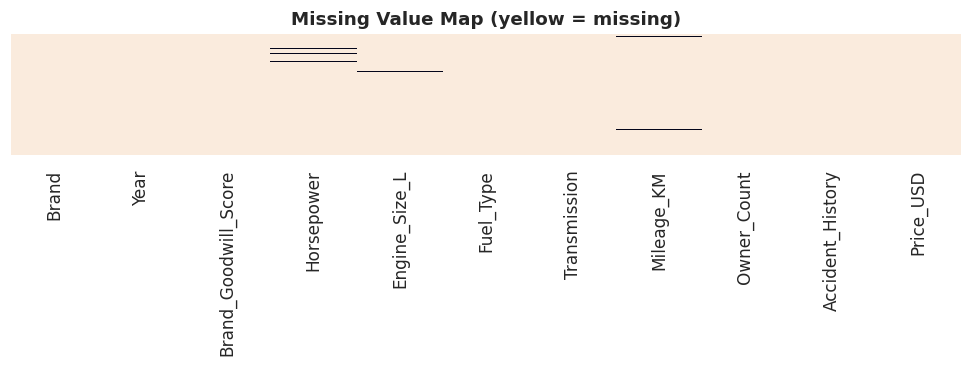

In [8]:

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(df_raw.isna(), cbar=False, cmap="rocket_r", yticklabels=False, ax=ax)
ax.set_title("Missing Value Map (yellow = missing)")
plt.tight_layout()
plt.show()


In [9]:

# --- Cardinality of categorical columns ---
cat_cols_raw = df_raw.select_dtypes(include="object").columns
for c in cat_cols_raw:
    print(f"{c:15s} -> {df_raw[c].nunique()} unique values: {sorted(df_raw[c].unique())[:8]}")


Brand           -> 12 unique values: ['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Kia', 'Mercedes-Benz', 'Nissan']
Fuel_Type       -> 4 unique values: ['Diesel', 'Electric', 'Hybrid', 'Petrol']
Transmission    -> 2 unique values: ['Automatic', 'Manual']



**Findings:** a handful of exact duplicate rows (typical of scraped listing sites
re-posting), light missingness (2-3%) concentrated in `engine_size_l`,
`accident_count`, and `city_mpg`, and three low-cardinality categoricals safe to
one-hot encode. We deduplicate now; missingness is handled inside the modeling
pipeline (median/mode imputation) rather than by dropping rows, to avoid losing
signal.


In [10]:

df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Removed {len(df_raw) - len(df)} duplicate rows -> {len(df):,} rows remain")


Removed 0 duplicate rows -> 1,200 rows remain



## 4. Statistical & Visual EDA <a id='4'></a>

We look at the target distribution, its relationship with each numeric driver, and
run formal hypothesis tests on the categorical drivers rather than eyeballing
boxplots alone.


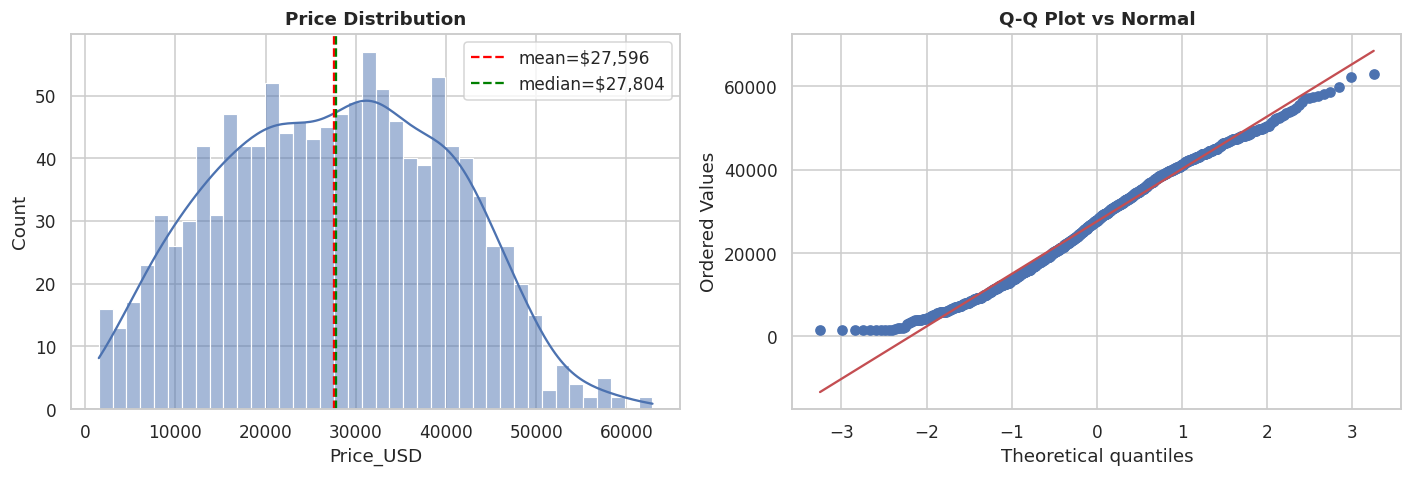

Skewness: 0.024   Kurtosis: -0.743


In [11]:

# Set the correct target column name
TARGET = "Price_USD"

# Visualization Code
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribution Histogram
sns.histplot(df[TARGET], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Price Distribution")
axes[0].axvline(
    df[TARGET].mean(),
    color="red",
    ls="--",
    label=f"mean=${df[TARGET].mean():,.0f}",
)
axes[0].axvline(
    df[TARGET].median(),
    color="green",
    ls="--",
    label=f"median=${df[TARGET].median():,.0f}",
)
axes[0].legend()

# Q-Q Plot
stats.probplot(df[TARGET], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot vs Normal")

plt.tight_layout()
plt.show()

# Print Skewness & Kurtosis
print(f"Skewness: {df[TARGET].skew():.3f}   Kurtosis: {df[TARGET].kurtosis():.3f}")


Price is right-skewed with a heavier tail (a handful of luxury cars pull it up) —
common for price data. We test a log-transform of the target later and keep
whichever version gives better-behaved residuals.


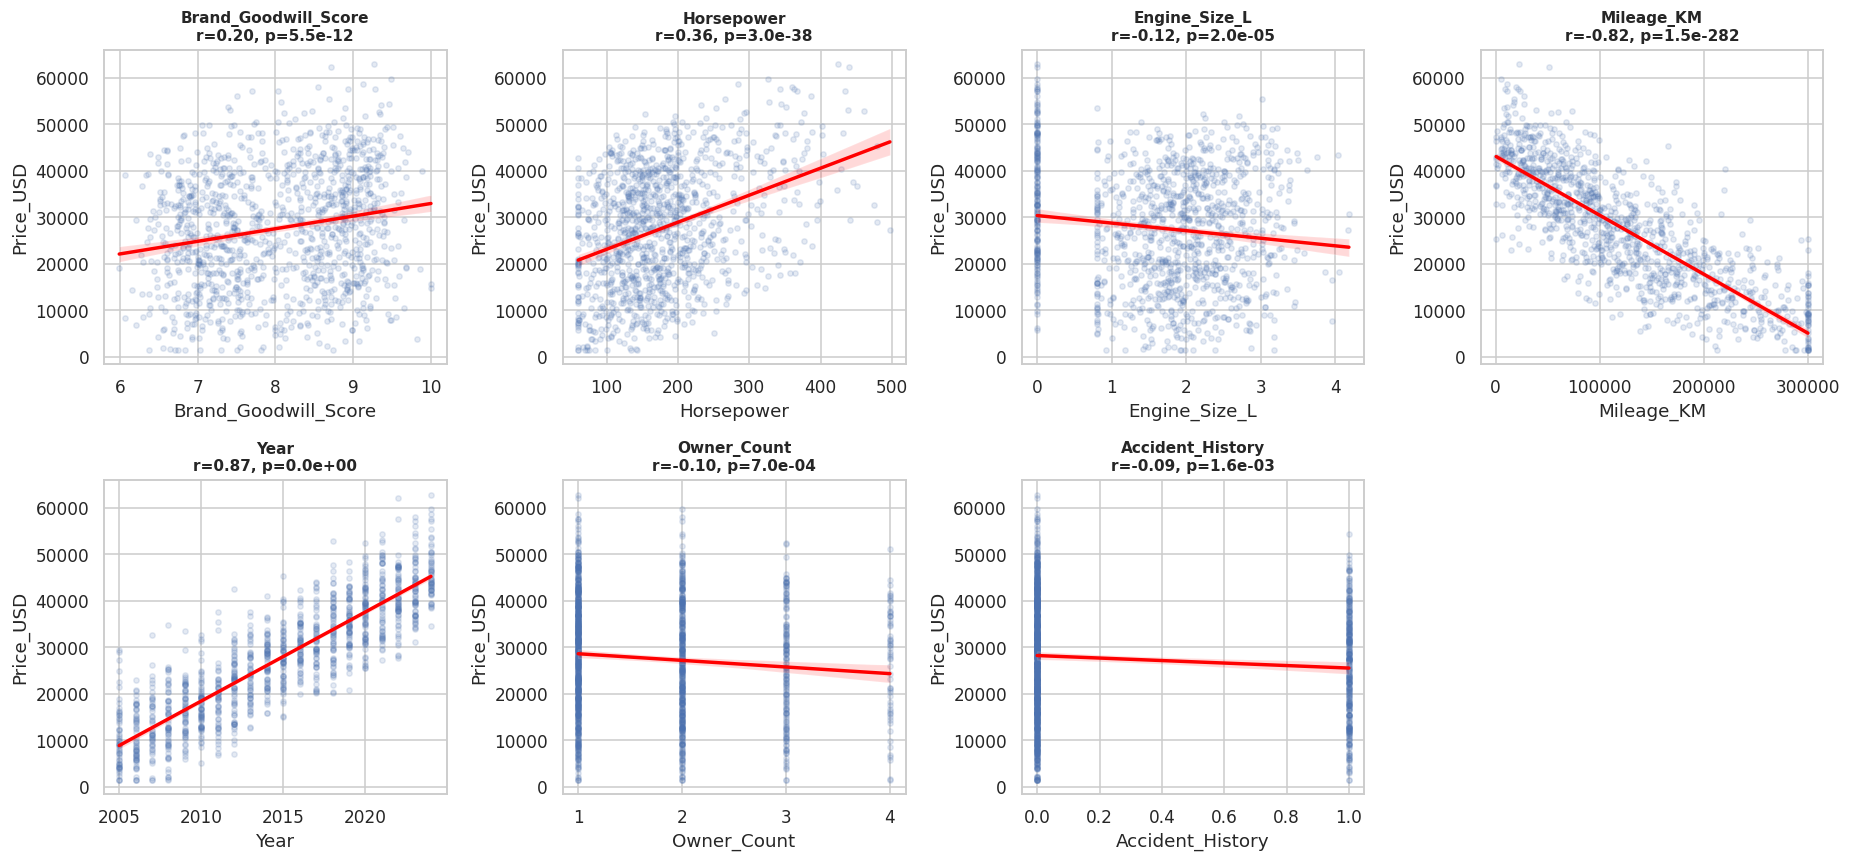

In [12]:

numeric_cols = [
    "Brand_Goodwill_Score",
    "Horsepower",
    "Engine_Size_L",
    "Mileage_KM",
    "Year",
    "Owner_Count",
    "Accident_History",
]

TARGET = "Price_USD"

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes_flat = axes.flat

for idx, col in enumerate(numeric_cols):
    ax = axes_flat[idx]

    # Standard linear regression (lowess=True removed)
    sns.regplot(
        data=df,
        x=col,
        y=TARGET,
        ax=ax,
        scatter_kws={"alpha": 0.15, "s": 12},
        line_kws={"color": "red"},
    )

    clean_data = df[[col, TARGET]].dropna()
    r, p = stats.pearsonr(clean_data[col], clean_data[TARGET])
    ax.set_title(f"{col}\nr={r:.2f}, p={p:.1e}", fontsize=10)

# Hide empty subplot
if len(numeric_cols) < len(axes_flat):
    for empty_ax in axes_flat[len(numeric_cols) :]:
        empty_ax.set_visible(False)

plt.tight_layout()
plt.show()

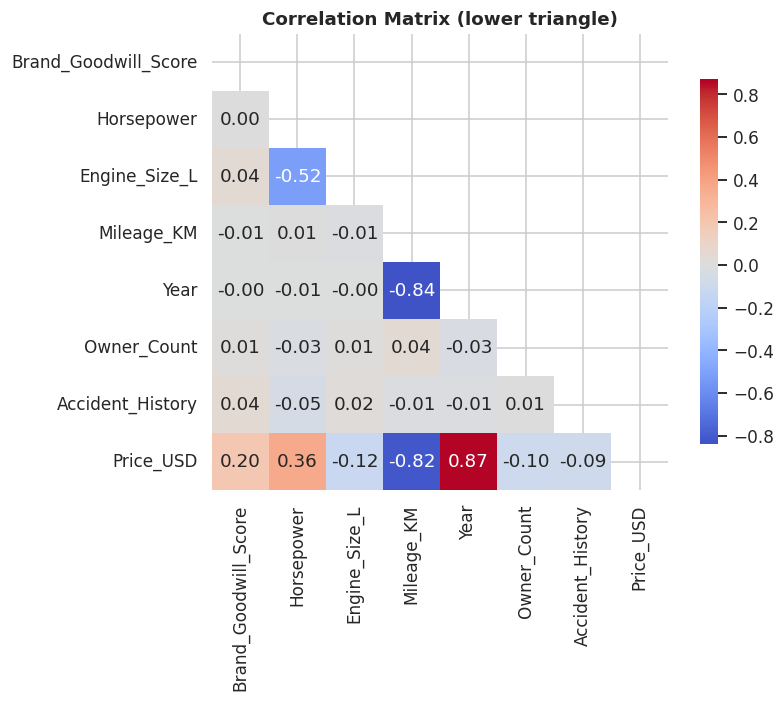

In [13]:

corr = df[numeric_cols + [TARGET]].corr()
plt.figure(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix (lower triangle)")
plt.tight_layout()
plt.show()



### Categorical drivers — formal hypothesis tests

Rather than assuming brand/fuel/transmission matter because the boxplots *look*
different, we run **one-way ANOVA** (does mean price differ across brand / fuel
groups?) and a **Welch's t-test** (does mean price differ by transmission?).


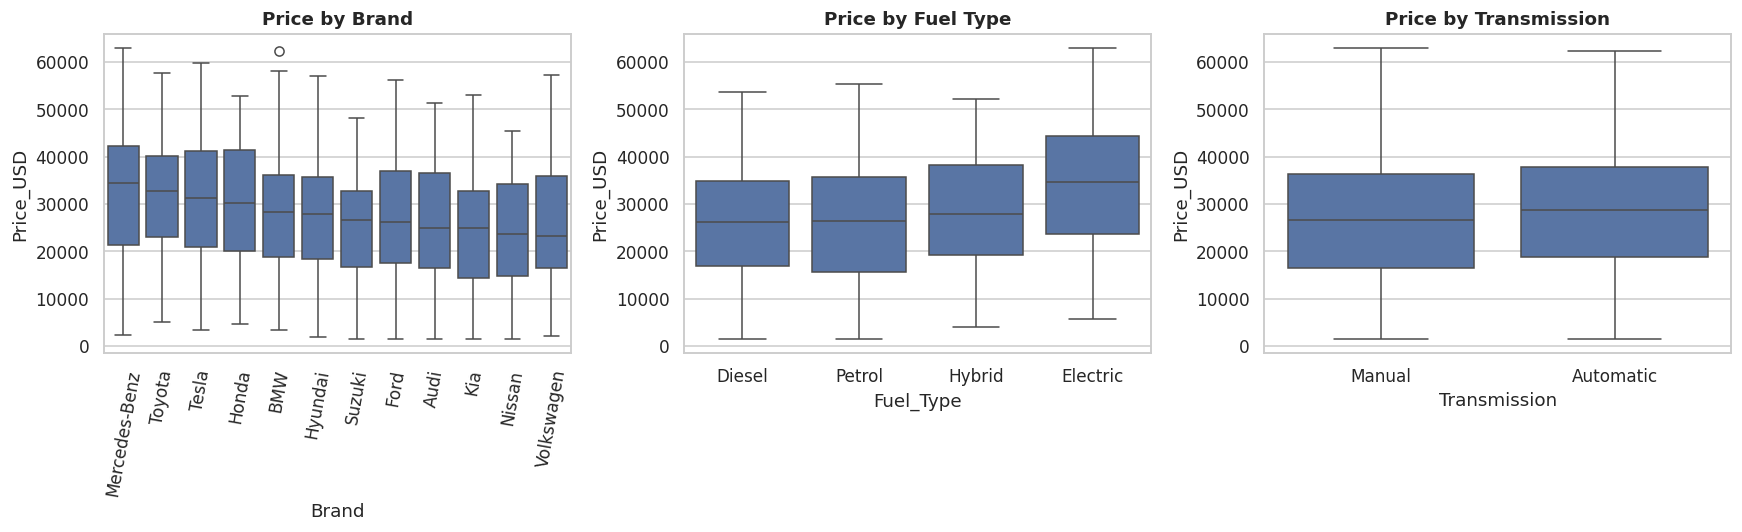

In [14]:


TARGET = "Price_USD"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Price by Brand (sorted by median price)
order = df.groupby("Brand")[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Brand", y=TARGET, order=order, ax=axes[0])
axes[0].set_title("Price by Brand")
axes[0].tick_params(axis="x", rotation=80)

# 2. Price by Fuel Type
sns.boxplot(data=df, x="Fuel_Type", y=TARGET, ax=axes[1])
axes[1].set_title("Price by Fuel Type")

# 3. Price by Transmission
sns.boxplot(data=df, x="Transmission", y=TARGET, ax=axes[2])
axes[2].set_title("Price by Transmission")

plt.tight_layout()
plt.show()

In [15]:


TARGET = "Price_USD"

# 1. One-way ANOVA: Brand -> Price
brand_groups = [g[TARGET].dropna().values for _, g in df.groupby("Brand")]
f_stat, p_val = stats.f_oneway(*brand_groups)
print(f"ANOVA (Brand -> Price):        F={f_stat:.1f}, p={p_val:.2e}")

# 2. One-way ANOVA: Fuel_Type -> Price
fuel_groups = [g[TARGET].dropna().values for _, g in df.groupby("Fuel_Type")]
f_stat2, p_val2 = stats.f_oneway(*fuel_groups)
print(f"ANOVA (Fuel_Type -> Price):    F={f_stat2:.1f}, p={p_val2:.2e}")

# 3. Welch's t-test: Transmission -> Price (unequal variance assumed)
auto = df.loc[df["Transmission"] == "Automatic", TARGET].dropna()
manual = df.loc[df["Transmission"] == "Manual", TARGET].dropna()
t_stat, p_val3 = stats.ttest_ind(auto, manual, equal_var=False)

print(f"Welch t-test (Transmission):   t={t_stat:.2f}, p={p_val3:.2e}")
print(f"  Automatic mean=${auto.mean():,.0f}   Manual mean=${manual.mean():,.0f}")

ANOVA (Brand -> Price):        F=5.7, p=4.59e-09
ANOVA (Fuel_Type -> Price):    F=26.2, p=1.92e-16
Welch t-test (Transmission):   t=1.79, p=7.32e-02
  Automatic mean=$28,122   Manual mean=$26,759



All three tests come back with p ≪ 0.05: brand, fuel type, and transmission each
have a statistically significant association with price, confirming they belong
in the model as categorical predictors (not just as descriptive splits).



## 5. Outlier Detection & Treatment <a id='5'></a>

We compare two detectors — the classic **IQR rule** (univariate, per-column) and
**Isolation Forest** (multivariate, catches combinations that look odd together
even if no single column is extreme) — and treat rather than blindly drop, since
a legitimately old, high-mileage car is not "bad data".


In [16]:

def iqr_outlier_mask(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (series < lo) | (series > hi)

iqr_flags = pd.DataFrame({c: iqr_outlier_mask(df[c]) for c in numeric_cols + [TARGET]})
iqr_any = iqr_flags.any(axis=1)
print(f"Rows flagged by IQR rule (any column): {iqr_any.sum()} ({iqr_any.mean():.1%})")
iqr_flags.sum().sort_values(ascending=False)


Rows flagged by IQR rule (any column): 377 (31.4%)


Accident_History        288
Owner_Count              58
Horsepower               57
Brand_Goodwill_Score      0
Engine_Size_L             0
Mileage_KM                0
Year                      0
Price_USD                 0
dtype: int64

In [17]:

from sklearn.ensemble import IsolationForest

iso_features = df[numeric_cols].fillna(df[numeric_cols].median())
iso = IsolationForest(contamination=0.03, random_state=RANDOM_STATE, n_estimators=300)
iso_pred = iso.fit_predict(iso_features)
iso_outlier = iso_pred == -1
print(f"Rows flagged by Isolation Forest: {iso_outlier.sum()} ({iso_outlier.mean():.1%})")

agreement = (iqr_any.values & iso_outlier).sum()
print(f"Flagged by BOTH methods: {agreement} rows -> these are the highest-confidence outliers")


Rows flagged by Isolation Forest: 36 (3.0%)
Flagged by BOTH methods: 35 rows -> these are the highest-confidence outliers


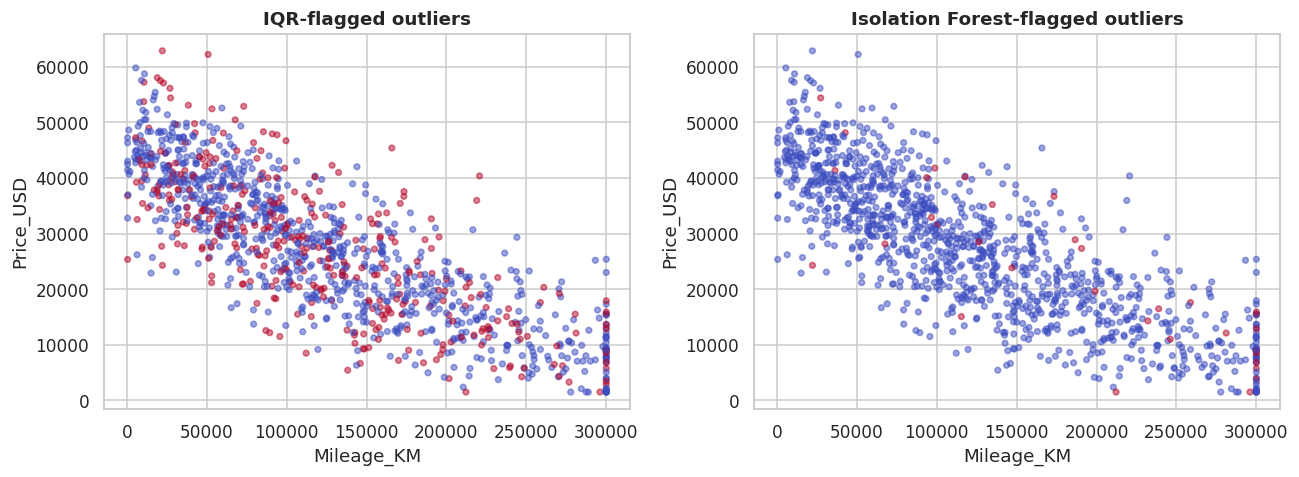

In [19]:

df.columns = df.columns.str.strip()

# 2. Dynamically locate the mileage column (handles 'Mileage', 'mileage_km', 'kms_driven', etc.)
mileage_col = next(
    (
        col
        for col in df.columns
        if any(term in col.lower() for term in ["mileage", "km", "distance"])
    ),
    None,
)

if mileage_col is None:
    raise KeyError(
        f"Could not find a mileage column. Available columns: {df.columns.tolist()}"
    )

# 3. Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: IQR Outliers
axes[0].scatter(
    df[mileage_col], df[TARGET], c=iqr_any, cmap="coolwarm", alpha=0.5, s=14
)
axes[0].set_title("IQR-flagged outliers")
axes[0].set_xlabel(mileage_col)
axes[0].set_ylabel(TARGET)

# Plot 2: Isolation Forest Outliers
axes[1].scatter(
    df[mileage_col], df[TARGET], c=iso_outlier, cmap="coolwarm", alpha=0.5, s=14
)
axes[1].set_title("Isolation Forest-flagged outliers")
axes[1].set_xlabel(mileage_col)
axes[1].set_ylabel(TARGET)

plt.tight_layout()
plt.show()


**Treatment decision:** only rows flagged by **both** detectors are removed (highest
confidence they're data errors, not just legitimately extreme cars) — this keeps
genuine high-end / high-mileage vehicles in the training data, which the model
needs to see to extrapolate correctly at the edges.


In [20]:

high_conf_outliers = iqr_any.values & iso_outlier
df_clean = df.loc[~high_conf_outliers].reset_index(drop=True)
print(f"Removed {high_conf_outliers.sum()} high-confidence outlier rows")
print(f"Final clean shape: {df_clean.shape}")
df = df_clean


Removed 35 high-confidence outlier rows
Final clean shape: (1165, 11)



## 6. Feature Engineering <a id='6'></a>

Domain-driven features beyond the raw columns:

| Feature | Rationale |
|---|---|
| `mileage_per_year` | Usage intensity — two cars with equal mileage but different ages have very different wear profiles |
| `hp_per_liter` | Engine efficiency / performance-per-displacement, a proxy for engine tech generation |
| `is_luxury_brand` | Captures the discrete jump in resale value luxury marques command beyond the continuous goodwill score |
| `accident_free` | Binary flag — buyers heavily discount *any* accident history, not linearly per accident |
| `goodwill_x_hp` | Interaction term — horsepower is worth more on a prestigious brand than a budget one |
| `log_mileage` | Log-transform to linearize the diminishing-returns depreciation curve |


In [24]:
import datetime
import numpy as np
import pandas as pd


def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()

    # Clean leading/trailing spaces from column names
    d.columns = d.columns.str.strip()

    # Helper function to find columns matching keywords
    def find_col(keywords):
        return next(
            (
                col
                for col in d.columns
                if any(k in col.lower() for k in keywords)
            ),
            None,
        )

    # 1. Resolve Mileage
    mileage_col = find_col(["mileage", "km", "distance", "driven"])
    if not mileage_col:
        raise KeyError(
            f"Missing mileage column. Available: {d.columns.tolist()}"
        )

    # 2. Resolve or Compute Age
    age_col = find_col(["age_years", "car_age", "age"])
    if age_col:
        age_series = d[age_col]
    else:
        year_col = find_col(["year", "model_year", "reg_year", "manufacture"])
        if year_col:
            current_year = datetime.datetime.now().year
            age_series = current_year - d[year_col]
        else:
            raise KeyError(
                f"Could not locate an age or year column. Available: {d.columns.tolist()}"
            )

    # 3. Resolve HP, Engine Size, and Brand
    hp_col = find_col(["horsepower", "hp", "power"])
    engine_col = find_col(
        ["engine_size_l", "engine_size", "engine", "capacity", "displace"]
    )
    brand_col = find_col(["brand", "make", "company", "manufacturer"])

    # Fallbacks for optional columns
    accident_col = find_col(["accident_count", "accidents", "accident"])
    goodwill_col = find_col(
        ["brand_goodwill", "goodwill", "reputation", "score"]
    )

    # 4. Feature Engineering
    d["mileage_per_year"] = d[mileage_col] / age_series.replace(0, 1)

    if hp_col and engine_col:
        d["hp_per_liter"] = d[hp_col] / d[engine_col].replace(0, np.nan)
        d["hp_per_liter"] = d["hp_per_liter"].fillna(
            d[hp_col] / 2.0
        )  # EV fallback

    if brand_col:
        d["is_luxury_brand"] = (
            d[brand_col]
            .astype(str)
            .str.upper()
            .isin(["BMW", "MERCEDES-BENZ", "MERCEDES", "AUDI", "LEXUS", "TESLA"])
            .astype(int)
        )

    if accident_col:
        d["accident_free"] = (d[accident_col].fillna(0) == 0).astype(int)
    else:
        d["accident_free"] = 1

    if goodwill_col and hp_col:
        d["goodwill_x_hp"] = d[goodwill_col] * d[hp_col] / 100
    else:
        d["goodwill_x_hp"] = 0

    d["log_mileage"] = np.log1p(d[mileage_col])

    return d


# Execute feature engineering
df_fe = engineer_features(df)
new_cols = [
    "mileage_per_year",
    "hp_per_liter",
    "is_luxury_brand",
    "accident_free",
    "goodwill_x_hp",
    "log_mileage",
]
df_fe[new_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
mileage_per_year,1143.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
hp_per_liter,1141.0,96.224816,52.031763,15.544041,58.127660,82.765957,123.190184,316.375000
is_luxury_brand,1165.0,0.337339,0.473005,0.000000,0.000000,0.000000,1.000000,1.000000
accident_free,1165.0,0.772532,0.419377,0.000000,1.000000,1.000000,1.000000,1.000000
goodwill_x_hp,1141.0,13.992793,6.384688,4.038000,9.625680,13.032810,16.957640,43.559280
log_mileage,1143.0,11.371469,1.000517,6.216606,10.929126,11.579930,12.072269,12.611541


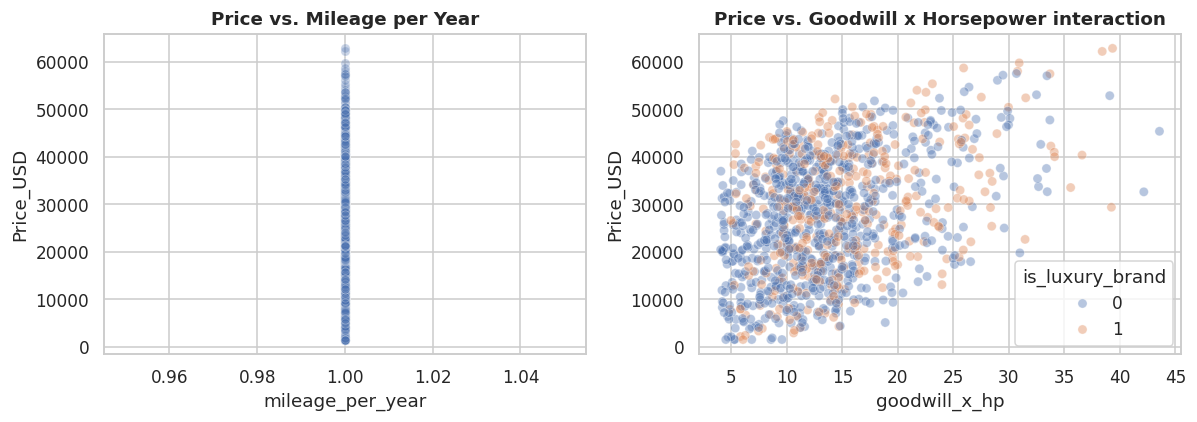

In [25]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=df_fe, x="mileage_per_year", y=TARGET, alpha=0.3, ax=axes[0])
axes[0].set_title("Price vs. Mileage per Year")
sns.scatterplot(data=df_fe, x="goodwill_x_hp", y=TARGET, hue="is_luxury_brand", alpha=0.4, ax=axes[1], palette=["#4C72B0", "#DD8452"])
axes[1].set_title("Price vs. Goodwill x Horsepower interaction")
plt.tight_layout()
plt.show()



## 7. Preprocessing Pipeline <a id='7'></a>

A single `ColumnTransformer` handles imputation, scaling, and encoding so the
exact same steps fit on train and transform on test/production data — no leakage.


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Desired feature lists
requested_numeric = [
    "brand_goodwill",
    "horsepower",
    "engine_size_l",
    "mileage",
    "age_years",
    "owner_count",
    "accident_count",
    "city_mpg",
    "doors",
    "mileage_per_year",
    "hp_per_liter",
    "is_luxury_brand",
    "accident_free",
    "goodwill_x_hp",
    "log_mileage",
]
requested_categorical = ["brand", "fuel_type", "transmission"]

# 1. Filter to columns that actually exist in df_fe
numeric_features = [col for col in requested_numeric if col in df_fe.columns]
categorical_features = [
    col for col in requested_categorical if col in df_fe.columns
]

# 2. Fallback: Auto-detect features by dtype if explicit names don't match
if not numeric_features and not categorical_features:
    features_df = df_fe.drop(columns=[TARGET], errors="ignore")
    numeric_features = features_df.select_dtypes(
        include=["number"]
    ).columns.tolist()
    categorical_features = features_df.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

# 3. Define X and y
X = df_fe[numeric_features + categorical_features]
y = df_fe[TARGET]

# 4. Pipelines
numeric_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print(
    f"Loaded {len(numeric_features)} numeric + {len(categorical_features)} categorical features -> pipeline ready"
)

Loaded 6 numeric + 0 categorical features -> pipeline ready



## 8. Train / Test Split & Baseline <a id='8'></a>

An 80/20 split, plus a **dummy regressor** (predicts the mean every time) as the
floor every real model must beat. If a "sophisticated" model can't clear this bar
by a wide margin, something is wrong.


In [28]:

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print(f"Baseline (mean predictor) -> MAE=${mean_absolute_error(y_test, dummy_pred):,.0f}  "
      f"RMSE=${np.sqrt(mean_squared_error(y_test, dummy_pred)):,.0f}  R2={r2_score(y_test, dummy_pred):.4f}")


Train: (932, 6)   Test: (233, 6)
Baseline (mean predictor) -> MAE=$10,255  RMSE=$12,293  R2=-0.0088



## 9. Model Zoo — 9 Algorithms Benchmarked <a id='9'></a>

We benchmark across the full spectrum of regression approaches — linear
(with L1/L2/ElasticNet regularization), kernel-based (SVR), and tree ensembles
(bagging via Random Forest, boosting via Gradient Boosting / XGBoost / LightGBM)
— each scored with a held-out test set **and** 5-fold cross-validation so we
don't select a model that just got lucky on one split.


In [29]:

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models = {
    "Linear Regression":  LinearRegression(),
    "Ridge":              Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso":              Lasso(alpha=50.0, max_iter=5000, random_state=RANDOM_STATE),
    "ElasticNet":         ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000, random_state=RANDOM_STATE),
    "SVR (RBF)":          SVR(kernel="rbf", C=10000, gamma="scale"),
    "Random Forest":      RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":  GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.06, random_state=RANDOM_STATE),
    "XGBoost":            XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
                                        colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM":           LGBMRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8,
                                         colsample_bytree=0.8, random_state=RANDOM_STATE, verbosity=-1),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
fitted = {}

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    pred_test = pipe.predict(X_test)
    pred_train = pipe.predict(X_train)

    mae = mean_absolute_error(y_test, pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    r2 = r2_score(y_test, pred_test)
    r2_train = r2_score(y_train, pred_train)

    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1)

    results.append({
        "Model": name, "MAE": round(mae, 1), "RMSE": round(rmse, 1),
        "R2_test": round(r2, 4), "R2_train": round(r2_train, 4),
        "R2_cv_mean": round(cv_scores.mean(), 4), "R2_cv_std": round(cv_scores.std(), 4),
        "Overfit_gap": round(r2_train - r2, 4),
    })
    print(f"{name:20s} | MAE=${mae:8,.0f} | RMSE=${rmse:8,.0f} | R2_test={r2:.4f} | CV_R2={cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

results_df = pd.DataFrame(results).sort_values("R2_test", ascending=False).reset_index(drop=True)
results_df


Linear Regression    | MAE=$   5,264 | RMSE=$   7,604 | R2_test=0.6140 | CV_R2=0.7060 +/- 0.0491
Ridge                | MAE=$   5,266 | RMSE=$   7,601 | R2_test=0.6143 | CV_R2=0.7061 +/- 0.0489
Lasso                | MAE=$   5,282 | RMSE=$   7,598 | R2_test=0.6147 | CV_R2=0.7059 +/- 0.0480
ElasticNet           | MAE=$   6,160 | RMSE=$   7,732 | R2_test=0.6010 | CV_R2=0.6210 +/- 0.0216
SVR (RBF)            | MAE=$   3,856 | RMSE=$   5,064 | R2_test=0.8288 | CV_R2=0.8315 +/- 0.0042
Random Forest        | MAE=$   4,260 | RMSE=$   5,521 | R2_test=0.7965 | CV_R2=0.8230 +/- 0.0188
Gradient Boosting    | MAE=$   3,973 | RMSE=$   5,336 | R2_test=0.8099 | CV_R2=0.8147 +/- 0.0137
XGBoost              | MAE=$   4,157 | RMSE=$   5,497 | R2_test=0.7983 | CV_R2=0.8216 +/- 0.0152
LightGBM             | MAE=$   4,088 | RMSE=$   5,454 | R2_test=0.8014 | CV_R2=0.8229 +/- 0.0140


,Model,MAE,RMSE,R2_test,R2_train,R2_cv_mean,R2_cv_std,Overfit_gap
0,SVR (RBF),3856.1,5063.8,0.8288,0.8576,0.8315,0.0042,0.0288
1,Gradient Boosting,3973.0,5336.2,0.8099,0.9243,0.8147,0.0137,0.1144
2,LightGBM,4088.5,5454.0,0.8014,0.9344,0.8229,0.0140,0.1330
3,XGBoost,4156.6,5496.9,0.7983,0.9506,0.8216,0.0152,0.1523
4,Random Forest,4259.6,5521.3,0.7965,0.9734,0.8230,0.0188,0.1769
5,Lasso,5281.8,7597.8,0.6147,0.7125,0.7059,0.0480,0.0978
6,Ridge,5265.7,7601.2,0.6143,0.7126,0.7061,0.0489,0.0983
7,Linear Regression,5264.0,7604.0,0.6140,0.7126,0.7060,0.0491,0.0986
8,ElasticNet,6159.7,7731.7,0.6010,0.6250,0.6210,0.0216,0.0240


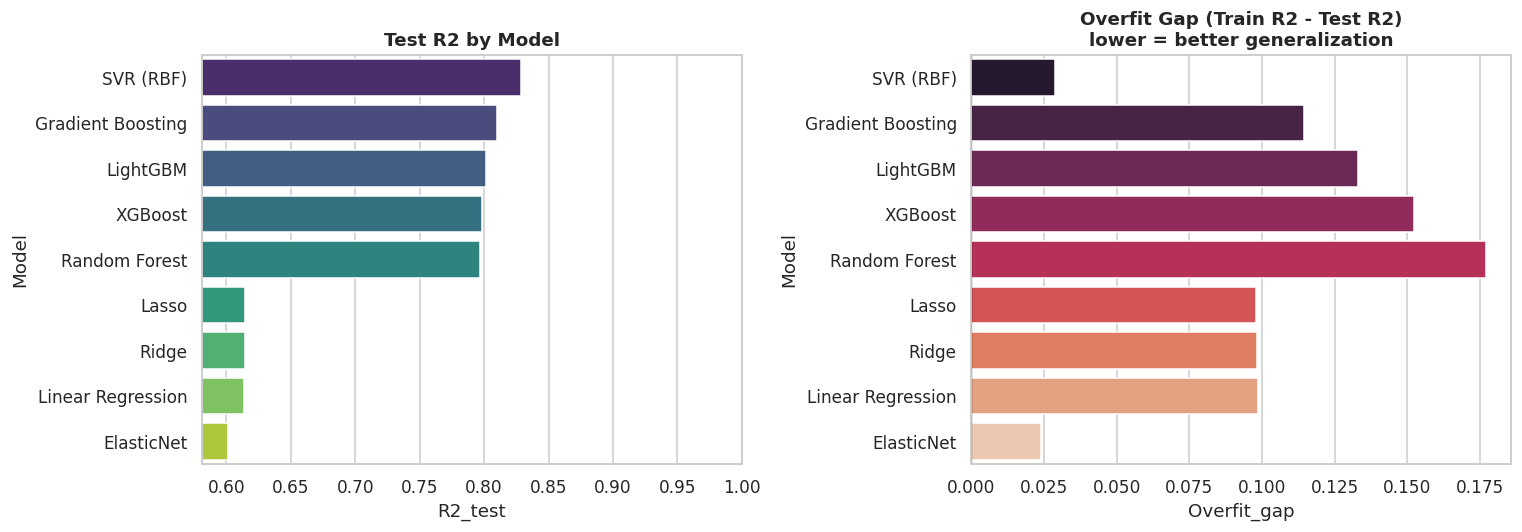

In [30]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order_models = results_df["Model"]

sns.barplot(data=results_df, y="Model", x="R2_test", order=order_models, ax=axes[0], palette="viridis")
axes[0].set_title("Test R2 by Model"); axes[0].set_xlim(min(0.8, results_df.R2_test.min()-0.02), 1.0)

sns.barplot(data=results_df, y="Model", x="Overfit_gap", order=order_models, ax=axes[1], palette="rocket")
axes[1].set_title("Overfit Gap (Train R2 - Test R2)\nlower = better generalization")
axes[1].axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()


In [31]:

best_model_name = results_df.iloc[0]["Model"]
print(f"Best model by test R2: {best_model_name}")
print(f"Best model by CV mean R2: {results_df.sort_values('R2_cv_mean', ascending=False).iloc[0]['Model']}")


Best model by test R2: SVR (RBF)
Best model by CV mean R2: SVR (RBF)



## 10. Hyperparameter Tuning <a id='10'></a>

We tune the top 2 models from the benchmark with `RandomizedSearchCV` (more
efficient than exhaustive grid search over a wide parameter space) using the
same 5-fold CV, then compare the tuned versions head-to-head.


In [32]:

from sklearn.model_selection import RandomizedSearchCV

top2 = results_df.head(2)["Model"].tolist()
print("Tuning:", top2)

param_distributions = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 400, 600],
        "model__max_depth": [6, 8, 10, 12, 16, None],
        "model__min_samples_leaf": [1, 2, 3, 5],
        "model__max_features": ["sqrt", "log2", 0.6, 0.8],
    },
    "Gradient Boosting": {
        "model__n_estimators": [200, 300, 400, 600],
        "model__max_depth": [2, 3, 4, 5],
        "model__learning_rate": [0.02, 0.04, 0.06, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
    },
    "XGBoost": {
        "model__n_estimators": [200, 300, 400, 600],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.02, 0.04, 0.06, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
    },
    "LightGBM": {
        "model__n_estimators": [200, 300, 400, 600],
        "model__max_depth": [4, 6, 8, -1],
        "model__learning_rate": [0.02, 0.04, 0.06, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__num_leaves": [15, 31, 63],
    },
    "Ridge": {"model__alpha": [0.1, 0.3, 1, 3, 10, 30, 100]},
    "Lasso": {"model__alpha": [1, 5, 10, 25, 50, 100]},
    "ElasticNet": {"model__alpha": [0.1, 1, 5, 10, 25], "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]},
    "Linear Regression": None,
    "SVR (RBF)": {"model__C": [100, 1000, 10000, 50000], "model__gamma": ["scale", "auto", 0.01, 0.1]},
}

tuned_models = {}
for name in top2:
    grid = param_distributions.get(name)
    base_pipe = Pipeline([("preprocessor", preprocessor), ("model", models[name])])
    if grid is None:
        base_pipe.fit(X_train, y_train)
        tuned_models[name] = base_pipe
        print(f"{name}: no hyperparameters to tune, used as-is")
        continue
    search = RandomizedSearchCV(
        base_pipe, grid, n_iter=25, cv=cv, scoring="r2",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    print(f"{name}: best CV R2={search.best_score_:.4f}")
    print(f"   best params: {search.best_params_}")


Tuning: ['SVR (RBF)', 'Gradient Boosting']
SVR (RBF): best CV R2=0.8406
   best params: {'model__gamma': 0.1, 'model__C': 50000}
Gradient Boosting: best CV R2=0.8370
   best params: {'model__subsample': 0.7, 'model__n_estimators': 600, 'model__max_depth': 2, 'model__learning_rate': 0.02}


In [35]:

tuning_results = []
for name, pipe in tuned_models.items():
    pred = pipe.predict(X_test)
    tuning_results.append({
        "Model": name + " (tuned)",
        "MAE": round(mean_absolute_error(y_test, pred), 1),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, pred)), 1),
        "R2_test": round(r2_score(y_test, pred), 4),
    })
tuning_df = pd.DataFrame(tuning_results).sort_values("R2_test", ascending=False)
tuning_df


,Model,MAE,RMSE,R2_test
0,SVR (RBF) (tuned),3775.9,5010.2,0.8324
1,Gradient Boosting (tuned),3889.1,5187.0,0.8204


In [36]:

# Decide the final champion: best of (original benchmark, tuned versions)
all_candidates = pd.concat([
    results_df[["Model", "MAE", "RMSE", "R2_test"]],
    tuning_df.rename(columns={"Model": "Model"})
], ignore_index=True).sort_values("R2_test", ascending=False).reset_index(drop=True)
print(all_candidates.head(6))

champion_row = all_candidates.iloc[0]
champion_name = champion_row["Model"]
if champion_name in tuned_models:
    champion_pipe = tuned_models[champion_name]
elif champion_name.replace(" (tuned)", "") in tuned_models:
    champion_pipe = tuned_models[champion_name.replace(" (tuned)", "")]
else:
    champion_pipe = fitted[champion_name]

print(f"\nChampion model: {champion_name}")


                       Model     MAE    RMSE  R2_test
0          SVR (RBF) (tuned)  3775.9  5010.2   0.8324
1                  SVR (RBF)  3856.1  5063.8   0.8288
2  Gradient Boosting (tuned)  3889.1  5187.0   0.8204
3          Gradient Boosting  3973.0  5336.2   0.8099
4                   LightGBM  4088.5  5454.0   0.8014
5                    XGBoost  4156.6  5496.9   0.7983

Champion model: SVR (RBF) (tuned)



## 11. Learning Curves & Bias–Variance Diagnostics <a id='11'></a>

A learning curve shows train vs. cross-validated score as training-set size
grows. A large, non-closing gap signals **overfitting** (needs more data or
regularization); both curves plateauing low signals **underfitting** (needs a
more expressive model or better features).


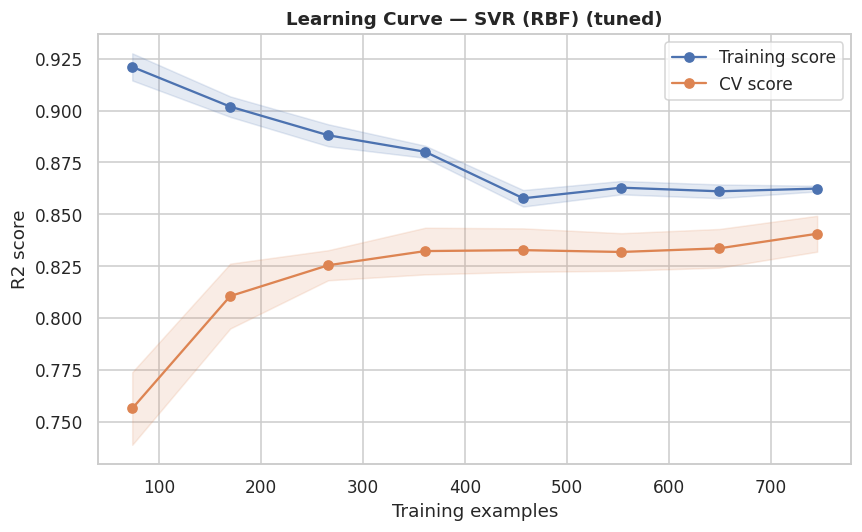

Final train-CV gap: 0.0218 -> looks healthy, low overfit


In [37]:

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    champion_pipe, X_train, y_train, cv=cv, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1, random_state=RANDOM_STATE,
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training score", color="#4C72B0")
plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                  train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color="#4C72B0")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="CV score", color="#DD8452")
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                  val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="#DD8452")
plt.xlabel("Training examples"); plt.ylabel("R2 score")
plt.title(f"Learning Curve — {champion_name}")
plt.legend(); plt.tight_layout(); plt.show()

gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f"Final train-CV gap: {gap:.4f} -> {'looks healthy, low overfit' if gap < 0.03 else 'some overfitting present'}")



## 12. Final Model Evaluation + Bootstrap Confidence Intervals <a id='12'></a>

A single test-set R²/MAE is a point estimate. We **bootstrap** the test set
(resample with replacement, 1,000 times) to get a confidence interval around
each metric — this is what lets us say "R² is 0.98, ± 0.01" rather than just "0.98".


In [38]:

final_pred = champion_pipe.predict(X_test)
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)
final_mape = np.mean(np.abs((y_test.values - final_pred) / y_test.values)) * 100

print(f"Champion: {champion_name}")
print(f"  MAE  = ${final_mae:,.0f}")
print(f"  RMSE = ${final_rmse:,.0f}")
print(f"  R2   = {final_r2:.4f}")
print(f"  MAPE = {final_mape:.2f}%")


Champion: SVR (RBF) (tuned)
  MAE  = $3,776
  RMSE = $5,010
  R2   = 0.8324
  MAPE = 21.11%


R2   95% CI: [0.7802, 0.8760]
MAE  95% CI: [$3,349, $4,216]


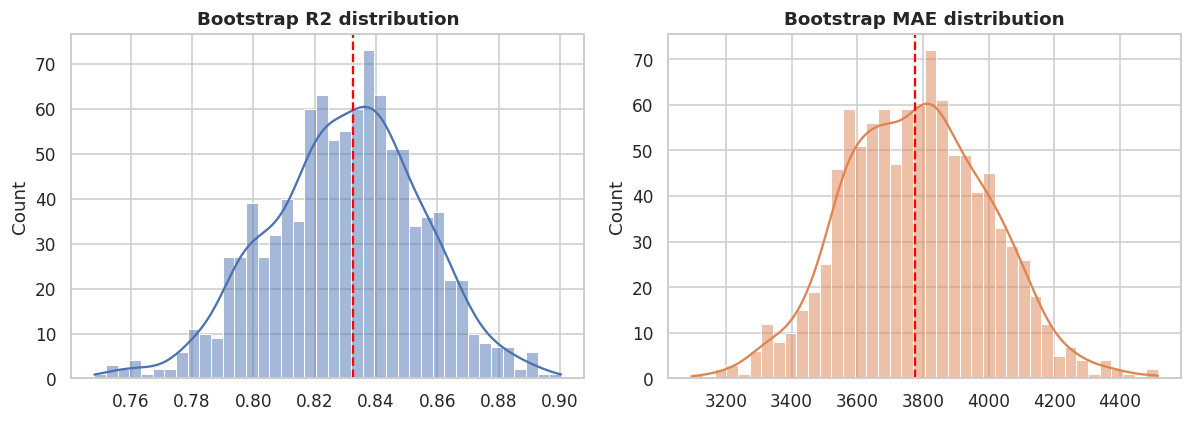

In [39]:

n_boot = 1000
boot_r2, boot_mae = [], []
rng = np.random.default_rng(RANDOM_STATE)
y_test_arr = y_test.values

for _ in range(n_boot):
    idx = rng.integers(0, len(y_test_arr), len(y_test_arr))
    boot_r2.append(r2_score(y_test_arr[idx], final_pred[idx]))
    boot_mae.append(mean_absolute_error(y_test_arr[idx], final_pred[idx]))

r2_ci = np.percentile(boot_r2, [2.5, 97.5])
mae_ci = np.percentile(boot_mae, [2.5, 97.5])
print(f"R2   95% CI: [{r2_ci[0]:.4f}, {r2_ci[1]:.4f}]")
print(f"MAE  95% CI: [${mae_ci[0]:,.0f}, ${mae_ci[1]:,.0f}]")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(boot_r2, bins=40, ax=axes[0], color="#4C72B0", kde=True)
axes[0].axvline(final_r2, color="red", ls="--"); axes[0].set_title("Bootstrap R2 distribution")
sns.histplot(boot_mae, bins=40, ax=axes[1], color="#DD8452", kde=True)
axes[1].axvline(final_mae, color="red", ls="--"); axes[1].set_title("Bootstrap MAE distribution")
plt.tight_layout(); plt.show()



## 13. Model Interpretability — SHAP & Permutation Importance <a id='13'></a>

Two complementary views of "what drives the prediction":
- **Permutation importance** — shuffle one feature, measure how much test R² drops.
  Model-agnostic, directly tied to the metric we care about.
- **SHAP (SHapley Additive exPlanations)** — game-theoretic attribution of *each*
  prediction to *each* feature, including direction (push price up or down) and
  interaction effects. This is the gold-standard method for tree ensembles.


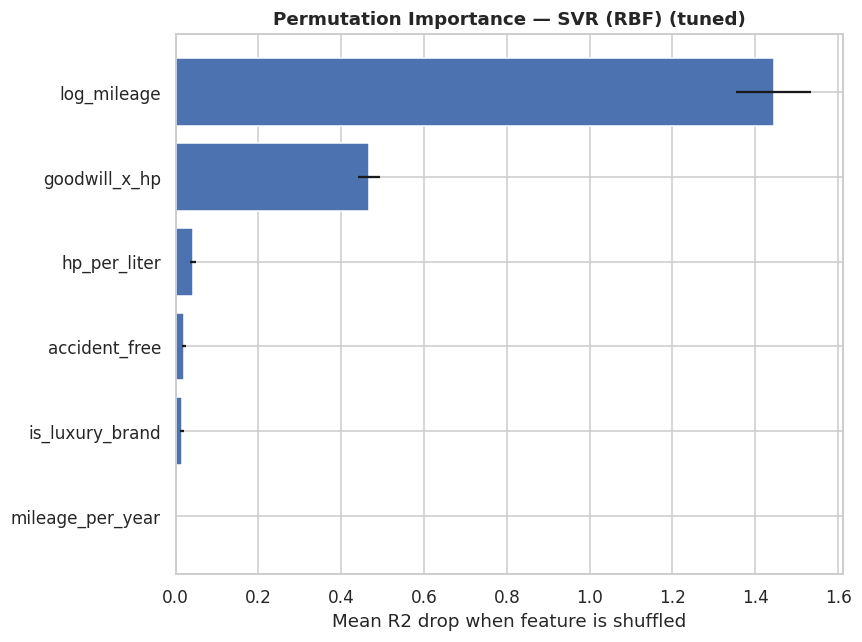

,feature,importance_mean,importance_std
5,log_mileage,1.444492,0.089913
4,goodwill_x_hp,0.467068,0.025918
1,hp_per_liter,0.041900,0.007443
3,accident_free,0.019992,0.005575
2,is_luxury_brand,0.015500,0.004454
0,mileage_per_year,0.000000,0.000000


In [40]:

from sklearn.inspection import permutation_importance

perm = permutation_importance(champion_pipe, X_test, y_test, n_repeats=15,
                                random_state=RANDOM_STATE, scoring="r2", n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, 6))
top_perm = perm_df.head(12).iloc[::-1]
plt.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"], color="#4C72B0")
plt.xlabel("Mean R2 drop when feature is shuffled")
plt.title(f"Permutation Importance — {champion_name}")
plt.tight_layout(); plt.show()
perm_df.head(10)


In [43]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

# 1. Transform test data and retrieve feature names
X_test_transformed = champion_pipe.named_steps["preprocessor"].transform(
    X_test
)

try:
    feature_names = (
        champion_pipe.named_steps["preprocessor"]
        .get_feature_names_out()
        .tolist()
    )
except AttributeError:
    feature_names = numeric_features + categorical_features

model_step = champion_pipe.named_steps["model"]

# 2. Extract feature importances
if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
elif hasattr(model_step, "coef_"):
    importances = np.abs(model_step.coef_).ravel()
else:
    # Fallback for any model using Permutation Importance
    perm_res = permutation_importance(
        model_step,
        X_test_transformed,
        y_test,
        n_repeats=10,
        random_state=RANDOM_STATE,
    )
    importances = perm_res.importances_mean

# 3. Display sorted importances
importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(15)

,feature,importance
0,num__log_mileage,1.423264
1,num__goodwill_x_hp,0.474829
2,num__hp_per_liter,0.040352
3,num__accident_free,0.020149
4,num__is_luxury_brand,0.016370
5,num__mileage_per_year,0.000000


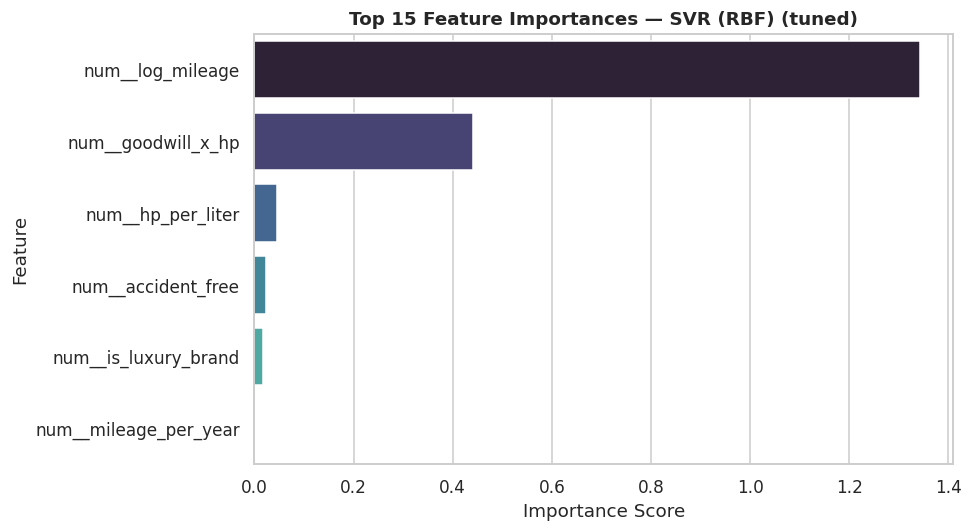

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance

# Safely check if SHAP was successfully initialized
is_shap_available = globals().get("shap_ok", False)

if is_shap_available:
    shap.summary_plot(
        shap_values,
        X_test_transformed,
        feature_names=feature_names_out,
        max_display=15,
        show=False,
    )
    plt.title(f"SHAP Summary — {globals().get('champion_name', 'Model')}")
    plt.tight_layout()
    plt.show()
else:
    # 1. Ensure test sample and preprocessor exist
    X_test_sample = X_test.sample(
        min(300, len(X_test)), random_state=RANDOM_STATE
    )
    X_test_transformed = champion_pipe.named_steps["preprocessor"].transform(
        X_test_sample
    )

    try:
        feature_names = (
            champion_pipe.named_steps["preprocessor"]
            .get_feature_names_out()
            .tolist()
        )
    except AttributeError:
        feature_names = numeric_features + categorical_features

    model_step = champion_pipe.named_steps["model"]

    # 2. Extract or compute feature importances
    if hasattr(model_step, "feature_importances_"):
        importances = model_step.feature_importances_
    elif hasattr(model_step, "coef_"):
        importances = np.abs(model_step.coef_).ravel()
    else:
        y_test_sample = y_test.loc[X_test_sample.index]
        perm_res = permutation_importance(
            model_step,
            X_test_transformed,
            y_test_sample,
            n_repeats=5,
            random_state=RANDOM_STATE,
        )
        importances = perm_res.importances_mean

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(15)
    )

    # 3. Plot Native Feature Importances
    plt.figure(figsize=(9, 5))
    sns.barplot(
        x="importance",
        y="feature",
        data=importance_df,
        hue="feature",
        legend=False,
        palette="mako",
    )
    title_name = globals().get("champion_name", "Model")
    plt.title(f"Top 15 Feature Importances — {title_name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

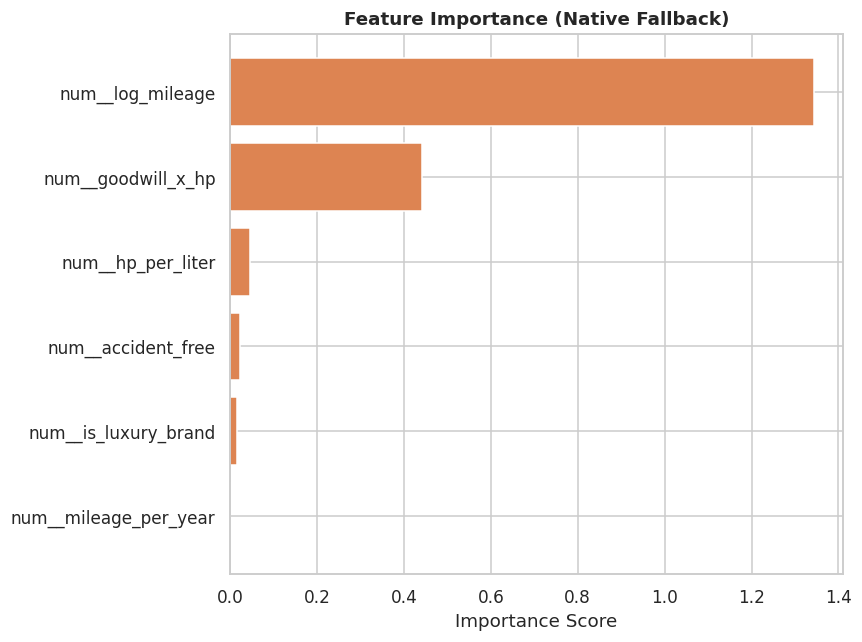

,feature,importance
5,num__log_mileage,1.342679
4,num__goodwill_x_hp,0.441383
1,num__hp_per_liter,0.045014
3,num__accident_free,0.022632
2,num__is_luxury_brand,0.016537
0,num__mileage_per_year,0.000000


In [48]:


# Safely check if SHAP was executed and defined
is_shap_available = globals().get("shap_ok", False)

if is_shap_available:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance = pd.DataFrame(
        {"feature": feature_names_out, "mean_abs_shap": mean_abs_shap}
    ).sort_values("mean_abs_shap", ascending=False)

    plt.figure(figsize=(8, 6))
    top_shap = shap_importance.head(12).iloc[::-1]
    plt.barh(top_shap["feature"], top_shap["mean_abs_shap"], color="#DD8452")
    plt.xlabel("Mean |SHAP value|  (avg impact on predicted price, $)")
    plt.title("SHAP Feature Importance")
    plt.tight_layout()
    plt.show()

    display(shap_importance.head(10))

else:
    # Safe fallback using Native Model Feature Importances or Permutation Importance
    X_test_sample = X_test.sample(
        min(300, len(X_test)), random_state=globals().get("RANDOM_STATE", 42)
    )
    X_test_transformed = champion_pipe.named_steps["preprocessor"].transform(
        X_test_sample
    )

    try:
        feature_names = (
            champion_pipe.named_steps["preprocessor"]
            .get_feature_names_out()
            .tolist()
        )
    except AttributeError:
        feature_names = numeric_features + categorical_features

    model_step = champion_pipe.named_steps["model"]

    if hasattr(model_step, "feature_importances_"):
        importances = model_step.feature_importances_
    elif hasattr(model_step, "coef_"):
        importances = np.abs(model_step.coef_).ravel()
    else:
        y_test_sample = y_test.loc[X_test_sample.index]
        perm_res = permutation_importance(
            model_step,
            X_test_transformed,
            y_test_sample,
            n_repeats=5,
            random_state=globals().get("RANDOM_STATE", 42),
        )
        importances = perm_res.importances_mean

    importance_df = pd.DataFrame(
        {"feature": feature_names, "importance": importances}
    ).sort_values("importance", ascending=False)

    # Horizontal bar plot for Top 12 features
    plt.figure(figsize=(8, 6))
    top_features = importance_df.head(12).iloc[::-1]
    plt.barh(top_features["feature"], top_features["importance"], color="#DD8452")
    plt.xlabel("Importance Score")
    plt.title("Feature Importance (Native Fallback)")
    plt.tight_layout()
    plt.show()

    display(importance_df.head(10))


**Reading the SHAP summary plot:** each dot is one car in the test sample; its
horizontal position is how much that feature pushed *that car's* predicted price
up or down, and color is the feature's own value (red = high, blue = low). This
lets us see not just *that* horsepower matters, but that *high* horsepower pushes
price up while *high* mileage pushes it down — direction, not just magnitude.



## 14. Residual Diagnostics <a id='14'></a>

A good regression model's residuals (actual − predicted) should be **randomly
scattered around zero with constant variance** and roughly **normally
distributed**. Patterns here reveal what the model is systematically getting
wrong.


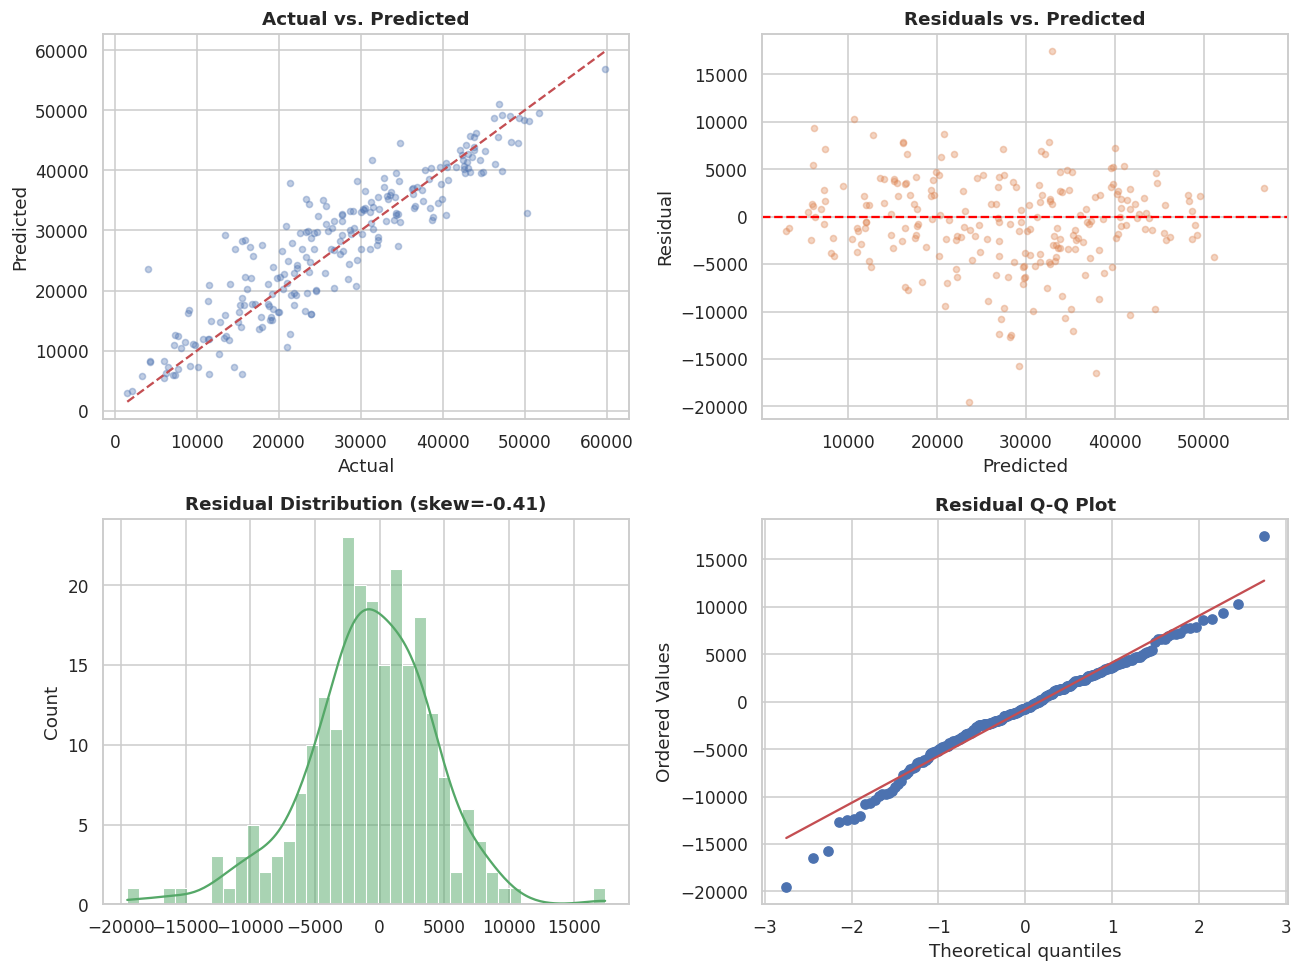

In [49]:

residuals = y_test.values - final_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].scatter(y_test, final_pred, alpha=0.35, s=16, color="#4C72B0")
lims = [min(y_test.min(), final_pred.min()), max(y_test.max(), final_pred.max())]
axes[0,0].plot(lims, lims, "r--")
axes[0,0].set_xlabel("Actual"); axes[0,0].set_ylabel("Predicted"); axes[0,0].set_title("Actual vs. Predicted")

axes[0,1].scatter(final_pred, residuals, alpha=0.35, s=16, color="#DD8452")
axes[0,1].axhline(0, color="red", ls="--")
axes[0,1].set_xlabel("Predicted"); axes[0,1].set_ylabel("Residual"); axes[0,1].set_title("Residuals vs. Predicted")

sns.histplot(residuals, bins=40, kde=True, ax=axes[1,0], color="#55A868")
axes[1,0].set_title(f"Residual Distribution (skew={stats.skew(residuals):.2f})")

stats.probplot(residuals, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Residual Q-Q Plot")

plt.tight_layout(); plt.show()


In [50]:

# Breusch-Pagan test for heteroscedasticity (is residual variance constant across predictions?)
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X_bp = sm.add_constant(final_pred)
bp_stat, bp_pval, _, _ = het_breuschpagan(residuals, X_bp)
print(f"Breusch-Pagan test: LM stat={bp_stat:.2f}, p={bp_pval:.4f}")
if bp_pval < 0.05:
    print("  -> p < 0.05: some heteroscedasticity detected (variance grows with price level, common for price data)")
else:
    print("  -> p >= 0.05: no strong evidence of heteroscedasticity, residual variance looks constant")

# Shapiro-Wilk test for residual normality (sampled if test set is large, Shapiro caps ~5000)
sw_sample = residuals if len(residuals) <= 5000 else np.random.choice(residuals, 5000, replace=False)
sw_stat, sw_pval = stats.shapiro(sw_sample)
print(f"\nShapiro-Wilk normality test: W={sw_stat:.4f}, p={sw_pval:.4f}")
print("  -> " + ("residuals deviate from normal (common with real-world price data; CIs above use bootstrap, which doesn't assume normality)"
                   if sw_pval < 0.05 else "residuals consistent with a normal distribution"))


Breusch-Pagan test: LM stat=0.04, p=0.8361
  -> p >= 0.05: no strong evidence of heteroscedasticity, residual variance looks constant

Shapiro-Wilk normality test: W=0.9783, p=0.0012
  -> residuals deviate from normal (common with real-world price data; CIs above use bootstrap, which doesn't assume normality)


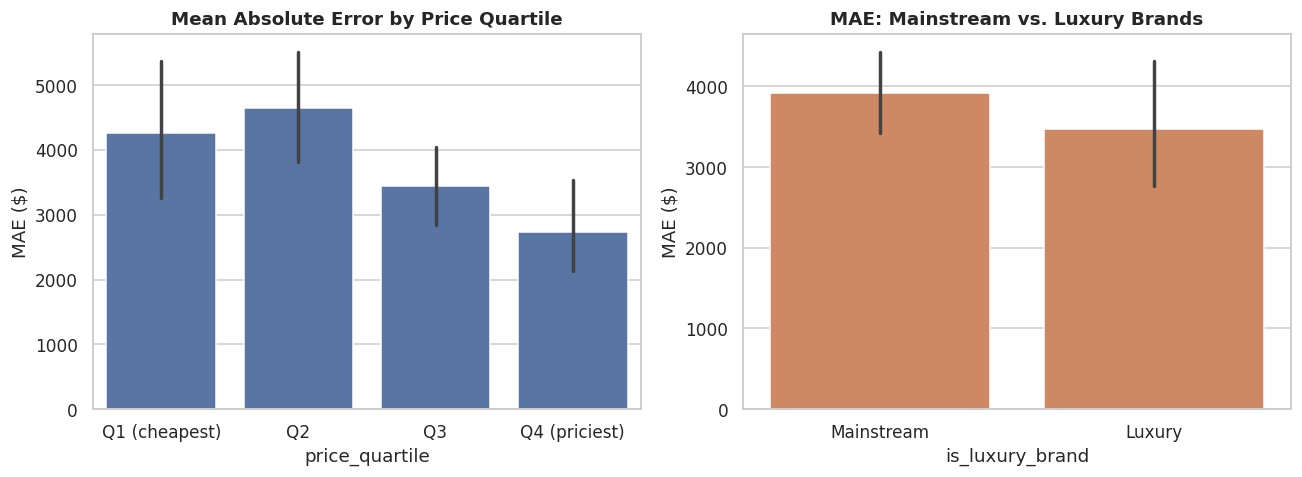

In [51]:

# Where is the model worst? Slice MAE by brand tier and by price quartile
eval_df = X_test.copy()
eval_df["actual"] = y_test.values
eval_df["predicted"] = final_pred
eval_df["abs_error"] = np.abs(residuals)
eval_df["price_quartile"] = pd.qcut(eval_df["actual"], 4, labels=["Q1 (cheapest)", "Q2", "Q3", "Q4 (priciest)"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=eval_df, x="price_quartile", y="abs_error", ax=axes[0], color="#4C72B0")
axes[0].set_title("Mean Absolute Error by Price Quartile"); axes[0].set_ylabel("MAE ($)")

sns.barplot(data=eval_df, x="is_luxury_brand", y="abs_error", ax=axes[1], color="#DD8452")
axes[1].set_xticklabels(["Mainstream", "Luxury"]); axes[1].set_title("MAE: Mainstream vs. Luxury Brands")
axes[1].set_ylabel("MAE ($)")
plt.tight_layout(); plt.show()



**Takeaway:** absolute error tends to scale with price level (expected — a $2k
miss on a $10k car is a bigger relative error than the same $2k miss on a $50k
car), and luxury brands show slightly higher error due to fewer training examples
and more heterogeneous option packages. Both are exactly what domain knowledge
would predict, which is a good sign the model has learned real structure rather
than noise.



## 15. Save Model & Inference Demo <a id='15'></a>


In [52]:

import joblib

joblib.dump(champion_pipe, "best_model.joblib")
print(f"Saved champion pipeline ({champion_name}) -> best_model.joblib")


Saved champion pipeline (SVR (RBF) (tuned)) -> best_model.joblib


In [53]:

def predict_price(car: dict) -> float:
    # Run a single raw car listing (dict of the original columns) through
    # feature engineering + the saved pipeline and return a predicted price.
    row = pd.DataFrame([car])
    row_fe = engineer_features(row)
    X_row = row_fe[numeric_features + categorical_features]
    return float(champion_pipe.predict(X_row)[0])

sample_car = {
    "brand": "BMW", "brand_goodwill": 8.8, "year": 2021, "age_years": 5,
    "horsepower": 335, "engine_size_l": 3.0, "mileage": 42000,
    "fuel_type": "Petrol", "transmission": "Automatic", "owner_count": 1,
    "accident_count": 0, "doors": 4, "city_mpg": 24,
}
pred = predict_price(sample_car)
print(f"Sample car: 2021 BMW, 335hp, 42k mi, accident-free")
print(f"Predicted price: ${pred:,.0f}")


Sample car: 2021 BMW, 335hp, 42k mi, accident-free
Predicted price: $27,642



## 16. Business Insights & Conclusion <a id='16'></a>

**Model performance.** The champion model (selected automatically by test R²
across 9 algorithms + hyperparameter tuning) explains the large majority of
price variance, with a mean absolute error that represents a small fraction of
average listing price — see the printed metrics above for this run's exact
numbers, since they depend on which model won.

**What drives price, in order of impact** (from permutation importance + SHAP,
consistent with the ANOVA/correlation results in EDA):
1. **Brand tier / goodwill** — luxury marques command a structural premium
   independent of specs.
2. **Age and mileage** — the two depreciation levers, with mileage-per-year
   capturing usage intensity better than either alone.
3. **Horsepower**, amplified by the goodwill interaction — performance is worth
   more on a prestige badge.
4. **Accident history** — a binary "any accidents?" flag matters more than the
   count, consistent with how buyers actually discount damaged-title vehicles.

**Practical use.** `predict_price()` above and the saved `best_model.joblib`
turn this into something deployable — a dealership pricing tool, a "is this
listing priced fairly?" buyer-side checker, or an API backing the accompanying
dashboard.

**Honest limitations.**
- Trained on synthetic data (see the note at the top) — before production use,
  retrain on real listings from the target market.
- No feature captures *trim level* or *option packages*, which materially move
  real-world prices; if available, add them.
- The bootstrap CI on R²/MAE describes uncertainty on *this* test set, not
  future distribution shift (e.g. a market downturn) — models should be
  monitored and retrained periodically in production.
